In [1]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import MDAnalysis as mda
from MDAnalysis.lib.distances import capped_distance


# ===========================================================================
 
DATASETS: dict[str, dict[str, Path]] = {
    "frag4-7": {
        "topology": Path(
            "frag4-7/out.center/prmtop.0d3_a_no_water_caprin.parm7"
        ),
        "trajectory": Path("frag4-7/out.center/ctstep1.b.ns.nc"),
    },
    "frag7-10": {
        "topology": Path(
            "frag7-10/out.center/prmtop.0d3_a_no_water_caprin.parm7"
        ),
        "trajectory": Path("frag7-10/out.center/ctstep1.b.ns.nc"),
    },
}

OUTPUT_DIR = Path("interaction_type_outputs_frag4-7_frag7-10")


NORMALIZE_BY_TOTAL_CHAINS = False

#  
# "sum": add the selected interaction probabilities; a cell may exceed 1.
# "clip": add them, then clip each cell to [0, 1].
COMBINE_MODE = "sum"
MAKE_HEATMAPS = True

THREE_INTERACTIONS = {
    "salt_bridge",
    "pi_pi",
    "cation_pi",
}

# Cutoffs
PI_PI_MAX_DIST = 7.0
PI_PI_MIN_ANGLE_DEG = 0.0
PI_PI_MAX_ANGLE_DEG = 45.0
CATION_PI_MAX_DIST = 6.0
SALT_BRIDGE_MAX_DIST = 4.0
HYDROPHOBIC_MAX_DIST = 5.0
POLAR_MAX_DIST = 3.5

USE_PBC_IF_AVAILABLE = True


# ===========================================================================
# General atom-name definitions
# ===========================================================================
BACKBONE_NAMES = {"N", "CA", "C", "O"}
POLAR_BACKBONE_ATOMS = ["N", "O"]

AROMATIC_RING_ATOMS = {
    "TYR": ["CG", "CD2", "CE2", "CZ", "CE1", "CD1"],
    "PHE": ["CG", "CD2", "CE2", "CZ", "CE1", "CD1"],
    "TRP": ["CE2", "CD2", "CE3", "CZ3", "CH2", "CZ2"],
}

CATION_PI_GROUP_ATOMS = {
    "ARG": ["CZ"],
    "LYS": ["NZ"],
}

SALT_BRIDGE_CATION_ATOMS = {
    "ARG": ["NH1", "NH2"],
    "LYS": ["NZ"],
    "HIP": ["ND1", "NE2"],
}

ANION_GROUP_ATOMS = {
    "ASP": ["OD1", "OD2"],
    "GLU": ["OE1", "OE2"],
}

HYDROPHOBIC_RESIDUES = {
    "ALA", "CYS", "PHE", "GLY", "ILE",
    "LEU", "MET", "PRO", "VAL", "TRP"
}

POLAR_SIDECHAIN_ATOMS = {
    "SER": ["OG"],
    "THR": ["OG1"],
    "ASN": ["OD1", "ND2"],
    "GLN": ["OE1", "NE2"],
    "TYR": ["OH"],
}


@dataclass
class ResidueFeature:
    resid: int
    resname: str
    ring_atom_indices: np.ndarray | None = None
    cation_pi_atom_indices: np.ndarray | None = None
    salt_bridge_cation_atom_indices: np.ndarray | None = None
    anion_atom_indices: np.ndarray | None = None
    hydrophobic_atom_indices: np.ndarray | None = None
    polar_sidechain_atom_indices: np.ndarray | None = None
    polar_backbone_atom_indices: np.ndarray | None = None


def unit_vector(v: np.ndarray) -> np.ndarray | None:
    n = np.linalg.norm(v)
    if n < 1e-12:
        return None
    return v / n


def plane_normal(points: np.ndarray) -> np.ndarray | None:
    if points.shape[0] < 3:
        return None
    centered = points - points.mean(axis=0)
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    return unit_vector(vh[-1])


def acute_angle_deg_between(v1: np.ndarray, v2: np.ndarray) -> float | None:
    u1 = unit_vector(v1)
    u2 = unit_vector(v2)
    if u1 is None or u2 is None:
        return None
    cosang = np.clip(np.abs(np.dot(u1, u2)), 0.0, 1.0)
    return float(np.degrees(np.arccos(cosang)))


def get_box(ts) -> np.ndarray | None:
    if not USE_PBC_IF_AVAILABLE:
        return None
    dims = getattr(ts, "dimensions", None)
    if dims is None or len(dims) < 3:
        return None
    if np.any(np.isnan(dims[:3])) or np.any(dims[:3] <= 0):
        return None
    return dims


def hydrophobic_sidechain_cs_indices(res) -> np.ndarray:
    if res.resname.upper() not in HYDROPHOBIC_RESIDUES:
        return np.asarray([], dtype=int)

    indices = [
        atom.index
        for atom in res.atoms
        if atom.name.upper() not in BACKBONE_NAMES
        and not atom.name.upper().startswith("H")
        and (
            atom.name.upper().startswith("C")
            or atom.name.upper().startswith("S")
        )
    ]
    return np.asarray(indices, dtype=int)


def named_atom_indices(res, atom_names: list[str]) -> np.ndarray:
    wanted = {a.upper() for a in atom_names}
    indices = [
        atom.index
        for atom in res.atoms
        if atom.name.upper() in wanted
    ]
    return np.asarray(indices, dtype=int)


def build_residue_features(u: mda.Universe) -> dict[int, ResidueFeature]:
    feats = {}

    for res in u.residues:
        resid = int(res.resid)
        resname = res.resname.upper()

        hydrophobic_idx = None
        ring_idx = None
        cation_pi_idx = None
        salt_bridge_cation_idx = None
        anion_idx = None
        polar_sidechain_idx = None
        polar_backbone_idx = None

        if resname in HYDROPHOBIC_RESIDUES:
            idx = hydrophobic_sidechain_cs_indices(res)
            if idx.size > 0:
                hydrophobic_idx = idx

        if resname in POLAR_SIDECHAIN_ATOMS:
            idx = named_atom_indices(res, POLAR_SIDECHAIN_ATOMS[resname])
            if idx.size > 0:
                polar_sidechain_idx = idx

        bb_idx = named_atom_indices(res, POLAR_BACKBONE_ATOMS)
        if bb_idx.size > 0:
            polar_backbone_idx = bb_idx

        if resname in AROMATIC_RING_ATOMS:
            idx = named_atom_indices(res, AROMATIC_RING_ATOMS[resname])
            if idx.size >= 3:
                ring_idx = idx

        if resname in CATION_PI_GROUP_ATOMS:
            idx = named_atom_indices(res, CATION_PI_GROUP_ATOMS[resname])
            if idx.size > 0:
                cation_pi_idx = idx

        if resname in SALT_BRIDGE_CATION_ATOMS:
            idx = named_atom_indices(res, SALT_BRIDGE_CATION_ATOMS[resname])
            if idx.size > 0:
                salt_bridge_cation_idx = idx

        if resname in ANION_GROUP_ATOMS:
            idx = named_atom_indices(res, ANION_GROUP_ATOMS[resname])
            if idx.size > 0:
                anion_idx = idx

        feats[resid] = ResidueFeature(
            resid=resid,
            resname=resname,
            ring_atom_indices=ring_idx,
            cation_pi_atom_indices=cation_pi_idx,
            salt_bridge_cation_atom_indices=salt_bridge_cation_idx,
            anion_atom_indices=anion_idx,
            hydrophobic_atom_indices=hydrophobic_idx,
            polar_sidechain_atom_indices=polar_sidechain_idx,
            polar_backbone_atom_indices=polar_backbone_idx,
        )

    return feats


def build_atomgroup_and_resid_map(u, residue_ids, features, attr_name):
    atom_indices = []
    resid_map = []

    for resid in residue_ids:
        feat = features.get(resid)
        if feat is None:
            continue

        idx = getattr(feat, attr_name)
        if idx is None or len(idx) == 0:
            continue

        atom_indices.extend(idx.tolist())
        resid_map.extend([resid] * len(idx))

    if not atom_indices:
        return None, None

    ag = u.atoms[np.asarray(atom_indices, dtype=int)]
    return ag, np.asarray(resid_map, dtype=int)


def increment_unique_residue_pairs_from_atom_contacts(
    interaction_name,
    pairs,
    src_atom_resids,
    tgt_atom_resids,
    pair_frame_counts,
):
    if pairs.size == 0:
        return

    resid_pairs = np.column_stack([
        src_atom_resids[pairs[:, 0]],
        tgt_atom_resids[pairs[:, 1]],
    ])
    resid_pairs = np.unique(resid_pairs, axis=0)

    for src_resid, tgt_resid in resid_pairs:
        pair_frame_counts[(interaction_name, int(src_resid), int(tgt_resid))] += 1


def residue_pairs_from_atom_contacts(
    pairs,
    src_atom_resids,
    tgt_atom_resids,
) -> set[tuple[int, int]]:
    if pairs.size == 0:
        return set()

    resid_pairs = np.column_stack([
        src_atom_resids[pairs[:, 0]],
        tgt_atom_resids[pairs[:, 1]],
    ])
    resid_pairs = np.unique(resid_pairs, axis=0)

    return {(int(src), int(tgt)) for src, tgt in resid_pairs}


def increment_residue_pair_set(interaction_name, resid_pair_set, pair_frame_counts):
    for src_resid, tgt_resid in resid_pair_set:
        pair_frame_counts[(interaction_name, src_resid, tgt_resid)] += 1


def ring_geometry(u, atom_indices):
    pts = u.atoms[atom_indices].positions
    centroid = pts.mean(axis=0)
    normal = plane_normal(pts)
    return centroid, normal


def point_geometry(u, atom_indices):
    pts = u.atoms[atom_indices].positions
    return pts.mean(axis=0)


def detect_pi_pi_for_frame(
    u,
    source_ring_resids,
    target_ring_resids,
    features,
    pair_frame_counts,
):
    target_geom = {}

    for resid in target_ring_resids:
        idx = features[resid].ring_atom_indices
        if idx is None:
            continue

        centroid, normal = ring_geometry(u, idx)
        if normal is not None:
            target_geom[resid] = (centroid, normal)

    for sresid in source_ring_resids:
        sidx = features[sresid].ring_atom_indices
        if sidx is None:
            continue

        scent, snorm = ring_geometry(u, sidx)
        if snorm is None:
            continue

        for tresid, (tcent, tnorm) in target_geom.items():
            d = np.linalg.norm(scent - tcent)
            angle = acute_angle_deg_between(snorm, tnorm)

            if angle is None:
                continue

            if (
                d <= PI_PI_MAX_DIST
                and PI_PI_MIN_ANGLE_DEG <= angle <= PI_PI_MAX_ANGLE_DEG
            ):
                pair_frame_counts[("pi_pi", int(sresid), int(tresid))] += 1


def detect_cation_pi_for_frame(
    u,
    source_cation_pi_resids,
    target_ring_resids,
    source_ring_resids,
    target_cation_pi_resids,
    features,
    pair_frame_counts,
):
    target_ring_centroids = {}

    for resid in target_ring_resids:
        idx = features[resid].ring_atom_indices
        if idx is not None:
            target_ring_centroids[resid] = point_geometry(u, idx)

    target_cat_centers = {}

    for resid in target_cation_pi_resids:
        idx = features[resid].cation_pi_atom_indices
        if idx is not None:
            target_cat_centers[resid] = point_geometry(u, idx)

    for sresid in source_cation_pi_resids:
        sidx = features[sresid].cation_pi_atom_indices
        if sidx is None:
            continue

        scat = point_geometry(u, sidx)

        for tresid, tcent in target_ring_centroids.items():
            d = np.linalg.norm(scat - tcent)
            if d <= CATION_PI_MAX_DIST:
                pair_frame_counts[("cation_pi", int(sresid), int(tresid))] += 1

    for sresid in source_ring_resids:
        sidx = features[sresid].ring_atom_indices
        if sidx is None:
            continue

        scent = point_geometry(u, sidx)

        for tresid, tcat in target_cat_centers.items():
            d = np.linalg.norm(tcat - scent)
            if d <= CATION_PI_MAX_DIST:
                pair_frame_counts[("cation_pi", int(sresid), int(tresid))] += 1


# ===========================================================================
# Input validation
# ===========================================================================
def get_dataset_jobs(
    datasets: dict[str, dict[str, Path]],
) -> list[tuple[str, Path, Path]]:
    """Validate the explicitly listed topology/trajectory pairs."""
    jobs: list[tuple[str, Path, Path]] = []

    for dataset, paths in datasets.items():
        topology = paths["topology"]
        trajectory = paths["trajectory"]

        if not topology.is_file():
            print(
                f"WARNING: topology not found for {dataset}: {topology}",
                flush=True,
            )
            continue

        if not trajectory.is_file():
            print(
                f"WARNING: trajectory not found for {dataset}: {trajectory}",
                flush=True,
            )
            continue

        print(
            f"Dataset {dataset}: topology={topology}, trajectory={trajectory}",
            flush=True,
        )
        jobs.append((dataset, topology, trajectory))

    return jobs


# ===========================================================================
# Chain detection
# ===========================================================================
def get_chain_sequences_and_real_resids(u: mda.Universe) -> list[list[tuple[int, str]]]:
    """
    Split topology into peptide copies using ACE ... NME blocks.
    Each returned chain is a list of real residues only: [(resid, resname), ...].
    """
    chains = []
    current = []
    inside_chain = False

    for res in u.residues:
        resname = str(res.resname).upper()
        resid = int(res.resid)

        if resname == "ACE":
            if inside_chain and current:
                chains.append(current)
            current = []
            inside_chain = True
            continue

        if not inside_chain:
            continue

        if resname == "NME":
            chains.append(current)
            current = []
            inside_chain = False
            continue

        current.append((resid, resname))

    if inside_chain and current:
        chains.append(current)

    return chains


def get_source_and_target_resids(u: mda.Universe):
    chains = get_chain_sequences_and_real_resids(u)

    if not chains:
        raise ValueError("Could not detect any ACE ... NME peptide chains in topology")

    source_chain = chains[0]
    source_resids = [resid for resid, _ in source_chain]
    source_resname_order = [resname for _, resname in source_chain]

    target_resids = []
    for chain in chains[1:]:
        target_resids.extend([resid for resid, _ in chain])

    n_total_chains = len(chains)
    n_target_chains = max(n_total_chains - 1, 0)

    return (
        source_resids,
        source_resname_order,
        target_resids,
        n_total_chains,
        n_target_chains,
    )


# ===========================================================================
# Main
# ===========================================================================
def main():
    outdir = Path(OUTPUT_DIR)
    outdir.mkdir(parents=True, exist_ok=True)

    jobs = get_dataset_jobs(DATASETS)

    if not jobs:
        print("ERROR: no valid dataset jobs found", file=sys.stderr)
        sys.exit(1)

    per_traj_rows = []
    mean_prob_accumulator = defaultdict(float)
    jobs_per_dataset = defaultdict(int)
    source_order_rows = []

    for dataset, parm7_path, traj_path in jobs:
        print(
            f"\nProcessing dataset {dataset}: {traj_path} with {parm7_path} ...",
            flush=True,
        )

        u = mda.Universe(str(parm7_path), str(traj_path))

        feats = build_residue_features(u)
        resid_to_resname = {rid: feat.resname for rid, feat in feats.items()}

        (
            source_resids_this,
            source_resname_order,
            target_resids_this,
            n_total_chains,
            n_target_chains,
        ) = get_source_and_target_resids(u)

        if len(source_resids_this) == 0:
            print(
                f"WARNING: no source residues found for dataset {dataset}; skipping",
                flush=True,
            )
            continue

        if len(target_resids_this) == 0:
            print(
                f"WARNING: no target residues found for dataset {dataset}; skipping",
                flush=True,
            )
            continue

        normalization_chain_count = (
            n_total_chains if NORMALIZE_BY_TOTAL_CHAINS else n_target_chains
        )

        if normalization_chain_count <= 0:
            print(
                f"WARNING: invalid normalization chain count for dataset "
                f"{dataset}; skipping",
                flush=True,
            )
            continue

        if jobs_per_dataset[dataset] == 0:
            for seq_pos, (src_resid, src_resname) in enumerate(
                zip(source_resids_this, source_resname_order),
                start=1,
            ):
                source_order_rows.append({
                    "dataset": dataset,
                    "sequence_position": seq_pos,
                    "src_resid": src_resid,
                    "src_resname": src_resname,
                })

        source_ring_resids = [
            r for r in source_resids_this
            if r in feats and feats[r].ring_atom_indices is not None
        ]
        target_ring_resids = [
            r for r in target_resids_this
            if r in feats and feats[r].ring_atom_indices is not None
        ]

        source_cation_pi_resids = [
            r for r in source_resids_this
            if r in feats and feats[r].cation_pi_atom_indices is not None
        ]
        target_cation_pi_resids = [
            r for r in target_resids_this
            if r in feats and feats[r].cation_pi_atom_indices is not None
        ]

        source_salt_cation_resids = [
            r for r in source_resids_this
            if r in feats and feats[r].salt_bridge_cation_atom_indices is not None
        ]
        target_salt_cation_resids = [
            r for r in target_resids_this
            if r in feats and feats[r].salt_bridge_cation_atom_indices is not None
        ]

        source_anion_resids = [
            r for r in source_resids_this
            if r in feats and feats[r].anion_atom_indices is not None
        ]
        target_anion_resids = [
            r for r in target_resids_this
            if r in feats and feats[r].anion_atom_indices is not None
        ]

        source_hydrophobic_resids = [
            r for r in source_resids_this
            if r in feats and feats[r].hydrophobic_atom_indices is not None
        ]
        target_hydrophobic_resids = [
            r for r in target_resids_this
            if r in feats and feats[r].hydrophobic_atom_indices is not None
        ]

        source_polar_sc_resids = [
            r for r in source_resids_this
            if r in feats and feats[r].polar_sidechain_atom_indices is not None
        ]
        target_polar_sc_resids = [
            r for r in target_resids_this
            if r in feats and feats[r].polar_sidechain_atom_indices is not None
        ]
        target_polar_bb_resids = [
            r for r in target_resids_this
            if r in feats and feats[r].polar_backbone_atom_indices is not None
        ]

        src_hydrophobic_ag, src_hydrophobic_atom_resids = build_atomgroup_and_resid_map(
            u, source_hydrophobic_resids, feats, "hydrophobic_atom_indices"
        )
        tgt_hydrophobic_ag, tgt_hydrophobic_atom_resids = build_atomgroup_and_resid_map(
            u, target_hydrophobic_resids, feats, "hydrophobic_atom_indices"
        )

        src_polar_sc_ag, src_polar_sc_atom_resids = build_atomgroup_and_resid_map(
            u, source_polar_sc_resids, feats, "polar_sidechain_atom_indices"
        )
        tgt_polar_sc_ag, tgt_polar_sc_atom_resids = build_atomgroup_and_resid_map(
            u, target_polar_sc_resids, feats, "polar_sidechain_atom_indices"
        )
        tgt_polar_bb_ag, tgt_polar_bb_atom_resids = build_atomgroup_and_resid_map(
            u, target_polar_bb_resids, feats, "polar_backbone_atom_indices"
        )

        src_salt_cation_ag, src_salt_cation_atom_resids = build_atomgroup_and_resid_map(
            u, source_salt_cation_resids, feats, "salt_bridge_cation_atom_indices"
        )
        tgt_salt_cation_ag, tgt_salt_cation_atom_resids = build_atomgroup_and_resid_map(
            u, target_salt_cation_resids, feats, "salt_bridge_cation_atom_indices"
        )

        src_anion_ag, src_anion_atom_resids = build_atomgroup_and_resid_map(
            u, source_anion_resids, feats, "anion_atom_indices"
        )
        tgt_anion_ag, tgt_anion_atom_resids = build_atomgroup_and_resid_map(
            u, target_anion_resids, feats, "anion_atom_indices"
        )

        pair_frame_counts = defaultdict(int)
        n_frames = 0

        print(
            f"  source_chain_len={len(source_resids_this)} "
            f"total_chains={n_total_chains} "
            f"target_chains={n_target_chains} "
            f"norm_chain_count={normalization_chain_count}",
            flush=True,
        )
        print(f"  source_resids={source_resids_this}", flush=True)
        print(f"  source_sequence_3letter={''.join(source_resname_order)}", flush=True)

        for ts in u.trajectory:
            n_frames += 1
            box = get_box(ts)

            # Hydrophobic
            if src_hydrophobic_ag is not None and tgt_hydrophobic_ag is not None:
                pairs = capped_distance(
                    src_hydrophobic_ag.positions,
                    tgt_hydrophobic_ag.positions,
                    HYDROPHOBIC_MAX_DIST,
                    box=box,
                    return_distances=False,
                )
                increment_unique_residue_pairs_from_atom_contacts(
                    "hydrophobic",
                    pairs,
                    src_hydrophobic_atom_resids,
                    tgt_hydrophobic_atom_resids,
                    pair_frame_counts,
                )

            # Polar
            polar_resid_pairs = set()

            if src_polar_sc_ag is not None and tgt_polar_sc_ag is not None:
                pairs = capped_distance(
                    src_polar_sc_ag.positions,
                    tgt_polar_sc_ag.positions,
                    POLAR_MAX_DIST,
                    box=box,
                    return_distances=False,
                )
                polar_resid_pairs |= residue_pairs_from_atom_contacts(
                    pairs,
                    src_polar_sc_atom_resids,
                    tgt_polar_sc_atom_resids,
                )

            if src_polar_sc_ag is not None and tgt_polar_bb_ag is not None:
                pairs = capped_distance(
                    src_polar_sc_ag.positions,
                    tgt_polar_bb_ag.positions,
                    POLAR_MAX_DIST,
                    box=box,
                    return_distances=False,
                )
                polar_resid_pairs |= residue_pairs_from_atom_contacts(
                    pairs,
                    src_polar_sc_atom_resids,
                    tgt_polar_bb_atom_resids,
                )

            increment_residue_pair_set(
                "polar",
                polar_resid_pairs,
                pair_frame_counts,
            )

            # Salt bridge: source cation to target anion
            if src_salt_cation_ag is not None and tgt_anion_ag is not None:
                pairs = capped_distance(
                    src_salt_cation_ag.positions,
                    tgt_anion_ag.positions,
                    SALT_BRIDGE_MAX_DIST,
                    box=box,
                    return_distances=False,
                )
                increment_unique_residue_pairs_from_atom_contacts(
                    "salt_bridge",
                    pairs,
                    src_salt_cation_atom_resids,
                    tgt_anion_atom_resids,
                    pair_frame_counts,
                )

            # Salt bridge: source anion to target cation
            if src_anion_ag is not None and tgt_salt_cation_ag is not None:
                pairs = capped_distance(
                    src_anion_ag.positions,
                    tgt_salt_cation_ag.positions,
                    SALT_BRIDGE_MAX_DIST,
                    box=box,
                    return_distances=False,
                )
                increment_unique_residue_pairs_from_atom_contacts(
                    "salt_bridge",
                    pairs,
                    src_anion_atom_resids,
                    tgt_salt_cation_atom_resids,
                    pair_frame_counts,
                )

            # Pi-pi
            if source_ring_resids and target_ring_resids:
                detect_pi_pi_for_frame(
                    u,
                    source_ring_resids,
                    target_ring_resids,
                    feats,
                    pair_frame_counts,
                )

            # Cation-pi
            if source_cation_pi_resids or target_cation_pi_resids:
                detect_cation_pi_for_frame(
                    u,
                    source_cation_pi_resids,
                    target_ring_resids,
                    source_ring_resids,
                    target_cation_pi_resids,
                    feats,
                    pair_frame_counts,
                )

        if n_frames == 0:
            print(f"WARNING: trajectory has 0 frames: {traj_path}; skipping", flush=True)
            continue

        for (interaction, src_resid, tgt_resid), count in sorted(pair_frame_counts.items()):
            prob = count / (n_frames * normalization_chain_count)

            per_traj_rows.append({
                "dataset": dataset,
                "traj_file": traj_path.name,
                "traj_path": str(traj_path),
                "parm7_file": parm7_path.name,
                "interaction": interaction,
                "src_resid": src_resid,
                "src_resname": resid_to_resname.get(src_resid, "UNK"),
                "tgt_resid": tgt_resid,
                "tgt_resname": resid_to_resname.get(tgt_resid, "UNK"),
                "frames_with_interaction": count,
                "n_frames": n_frames,
                "n_total_chains": n_total_chains,
                "n_target_chains": n_target_chains,
                "normalization_chain_count": normalization_chain_count,
                "probability": prob,
            })

            mean_prob_accumulator[
                (dataset, interaction, src_resid, tgt_resid)
            ] += prob

        jobs_per_dataset[dataset] += 1

        print(
            f"  done: dataset={dataset} traj={traj_path.name} "
            f"frames={n_frames} unique_pairs={len(pair_frame_counts)}",
            flush=True,
        )

    # ===========================================================================
    # Save per-trajectory results
    # ===========================================================================
    per_traj_df = pd.DataFrame(per_traj_rows)

    if not per_traj_df.empty:
        per_traj_df = per_traj_df.sort_values(
            ["dataset", "interaction", "traj_file", "src_resid", "tgt_resid"]
        ).reset_index(drop=True)

    per_traj_df.to_csv(
        outdir / "interaction_pair_probabilities_per_traj.csv",
        index=False,
    )

    # ===========================================================================
    # Save source residue order
    # ===========================================================================
    source_order_df = pd.DataFrame(source_order_rows)

    if not source_order_df.empty:
        source_order_df = (
            source_order_df
            .drop_duplicates(
                subset=["dataset", "sequence_position", "src_resid", "src_resname"]
            )
            .sort_values(["dataset", "sequence_position"])
            .reset_index(drop=True)
        )

    source_order_df.to_csv(
        outdir / "dataset_source_residue_order.csv",
        index=False,
    )

    # ===========================================================================
    # Average probability over trajectories inside each dataset
    # (Here each dataset has one trajectory, so the mean equals its probability.)
    # ===========================================================================
    mean_rows = []

    for (
        dataset,
        interaction,
        src_resid,
        tgt_resid,
    ), prob_sum in sorted(mean_prob_accumulator.items()):

        rows_match = per_traj_df[
            (per_traj_df["dataset"] == dataset)
            & (per_traj_df["interaction"] == interaction)
            & (per_traj_df["src_resid"] == src_resid)
            & (per_traj_df["tgt_resid"] == tgt_resid)
        ]

        mean_rows.append({
            "dataset": dataset,
            "interaction": interaction,
            "src_resid": src_resid,
            "src_resname": rows_match["src_resname"].iloc[0],
            "tgt_resid": tgt_resid,
            "tgt_resname": rows_match["tgt_resname"].iloc[0],
            "mean_probability_over_trajs": prob_sum / jobs_per_dataset[dataset],
            "n_trajs": jobs_per_dataset[dataset],
        })

    mean_df = pd.DataFrame(mean_rows)

    if not mean_df.empty:
        mean_df = mean_df.sort_values(
            ["dataset", "interaction", "src_resid", "tgt_resid"]
        ).reset_index(drop=True)

    mean_df.to_csv(
        outdir / "interaction_pair_probabilities_mean_over_trajs.csv",
        index=False,
    )

    # ===========================================================================
    # Source-residue totals after averaging over trajectories
    # ===========================================================================
    if not mean_df.empty:
        source_totals_df = (
            mean_df
            .groupby(
                ["dataset", "interaction", "src_resid", "src_resname"],
                as_index=False,
            )
            .agg(
                total_mean_probability=("mean_probability_over_trajs", "sum")
            )
            .sort_values(["dataset", "interaction", "src_resid"])
            .reset_index(drop=True)
        )
    else:
        source_totals_df = pd.DataFrame(
            columns=[
                "dataset",
                "interaction",
                "src_resid",
                "src_resname",
                "total_mean_probability",
            ]
        )

    source_totals_df.to_csv(
        outdir / "interaction_source_residue_totals_mean_over_trajs.csv",
        index=False,
    )

    # ===========================================================================
    # Dataset-level totals
    # ===========================================================================
    if not mean_df.empty:
        dataset_totals_df = (
            mean_df
            .groupby(["dataset", "interaction"], as_index=False)
            .agg(
                total_mean_probability=("mean_probability_over_trajs", "sum"),
                n_pairs=("mean_probability_over_trajs", "size"),
            )
            .sort_values(["dataset", "interaction"])
            .reset_index(drop=True)
        )
    else:
        dataset_totals_df = pd.DataFrame(
            columns=[
                "dataset",
                "interaction",
                "total_mean_probability",
                "n_pairs",
            ]
        )

    dataset_totals_df.to_csv(
        outdir / "interaction_dataset_totals_mean_over_trajs.csv",
        index=False,
    )

    save_dataset_specific_tables(
        datasets=list(DATASETS),
        outdir=outdir,
        per_traj_df=per_traj_df,
        mean_df=mean_df,
        source_order_df=source_order_df,
        source_totals_df=source_totals_df,
        dataset_totals_df=dataset_totals_df,
    )

    # ===========================================================================
    # Combined matrices (all types together, and the 3-type subset together)
    # ===========================================================================
    build_combined_matrices(
        mean_df=mean_df,
        dataset_inputs=DATASETS,
        outdir=outdir,
        interactions_to_include=None,
        folder_name="dataset_matrices-include-5-type-interactions",
        filename_suffix="all_5_interactions",
        title_suffix="all five interaction types",
    )

    build_combined_matrices(
        mean_df=mean_df,
        dataset_inputs=DATASETS,
        outdir=outdir,
        interactions_to_include=THREE_INTERACTIONS,
        folder_name="dataset_matrices-include-3-type-interactions",
        filename_suffix="saltbridge_pipi_cationpi",
        title_suffix="salt bridge + pi-pi + cation-pi",
    )

    # ===========================================================================
    # NEW: one matrix CSV (+ heatmap) per individual interaction type.
    # Each matrix has shape (n_source_residues x n_target_residues), i.e.
    # 16x16 for frag4-7 / frag7-10 if each peptide chain has 16 real residues.
    # ===========================================================================
    build_per_interaction_type_matrices(
        mean_df=mean_df,
        dataset_inputs=DATASETS,
        outdir=outdir,
    )

    print("\nFinished.")
    print(f"Saved in: {outdir.resolve()}")
    print(f"Per-trajectory results:")
    print(f"  {outdir / 'interaction_pair_probabilities_per_traj.csv'}")
    print(f"Mean-over-trajectories results:")
    print(f"  {outdir / 'interaction_pair_probabilities_mean_over_trajs.csv'}")
    print(f"Source residue totals:")
    print(f"  {outdir / 'interaction_source_residue_totals_mean_over_trajs.csv'}")
    print(f"Dataset totals:")
    print(f"  {outdir / 'interaction_dataset_totals_mean_over_trajs.csv'}")
    print(f"Source residue order:")
    print(f"  {outdir / 'dataset_source_residue_order.csv'}")
    print(f"Per-interaction-type matrices:")
    print(f"  {outdir / '<dataset>' / 'dataset_matrices-single-type-<interaction>'}")


def save_dataset_specific_tables(
    datasets: list[str],
    outdir: Path,
    per_traj_df: pd.DataFrame,
    mean_df: pd.DataFrame,
    source_order_df: pd.DataFrame,
    source_totals_df: pd.DataFrame,
    dataset_totals_df: pd.DataFrame,
) -> None:
    """Write a complete set of CSV tables inside each dataset folder."""
    tables = {
        "interaction_pair_probabilities_per_traj.csv": per_traj_df,
        "interaction_pair_probabilities_mean_over_trajs.csv": mean_df,
        "dataset_source_residue_order.csv": source_order_df,
        "interaction_source_residue_totals_mean_over_trajs.csv": (
            source_totals_df
        ),
        "interaction_dataset_totals_mean_over_trajs.csv": dataset_totals_df,
    }

    for dataset in datasets:
        safe_dataset = dataset.replace("/", "_").replace(" ", "_")
        dataset_dir = outdir / safe_dataset
        dataset_dir.mkdir(parents=True, exist_ok=True)

        for filename, table in tables.items():
            if "dataset" in table.columns:
                selected = table[table["dataset"] == dataset].copy()
            else:
                selected = table.copy()

            selected.to_csv(dataset_dir / filename, index=False)


def build_resid_to_position_maps(
    u: mda.Universe,
) -> tuple[dict[int, int], dict[int, int], dict[int, str]]:
    """
    Map topology residue IDs to 1-based sequence positions.

    The first peptide copy is the source chain. All later peptide copies are
    targets, and equivalent target positions are folded onto the same column.
    """
    chains = get_chain_sequences_and_real_resids(u)

    source_map: dict[int, int] = {}
    target_map: dict[int, int] = {}
    pos_resname: dict[int, str] = {}

    if not chains:
        return source_map, target_map, pos_resname

    for position, (resid, resname) in enumerate(chains[0], start=1):
        source_map[int(resid)] = position
        pos_resname[position] = str(resname).upper()

    for chain in chains[1:]:
        for position, (resid, _resname) in enumerate(chain, start=1):
            target_map[int(resid)] = position

    return source_map, target_map, pos_resname


def build_combined_matrices(
    mean_df: pd.DataFrame,
    dataset_inputs: dict[str, dict[str, Path]],
    outdir: Path,
    interactions_to_include: set[str] | None,
    folder_name: str,
    filename_suffix: str,
    title_suffix: str,
) -> None:
    """
    Build one source-position x target-position matrix for each dataset.

    Parameters
    ----------
    interactions_to_include
        None includes every detected interaction type. A set includes only the
        named types.
    """
    if mean_df.empty:
        print(f"WARNING: no interaction rows available for {folder_name}.")
        return

    required_columns = {
        "dataset",
        "interaction",
        "src_resid",
        "tgt_resid",
        "mean_probability_over_trajs",
    }
    missing = required_columns.difference(mean_df.columns)
    if missing:
        raise ValueError(
            "Cannot build matrices; mean table is missing columns: "
            + ", ".join(sorted(missing))
        )

    for dataset, paths in dataset_inputs.items():
        topology = paths["topology"]
        topology_only = mda.Universe(str(topology))
        source_map, target_map, pos_resname = build_resid_to_position_maps(
            topology_only
        )

        if not source_map or not target_map:
            raise ValueError(
                "Could not map source/target residues from ACE ... NME "
                f"chains in topology {topology}"
            )

        n_source = max(source_map.values())
        n_target = max(target_map.values())

        row_labels = [
            f"{pos_resname.get(position, 'UNK')}{position}"
            for position in range(1, n_source + 1)
        ]
        col_labels = [
            f"{pos_resname.get(position, 'UNK')}{position}"
            for position in range(1, n_target + 1)
        ]

        safe_dataset = dataset.replace("/", "_").replace(" ", "_")
        matrix_dir = outdir / safe_dataset / folder_name
        matrix_dir.mkdir(parents=True, exist_ok=True)

        subset = mean_df[mean_df["dataset"] == dataset].copy()

        if interactions_to_include is not None:
            subset = subset[
                subset["interaction"].isin(interactions_to_include)
            ].copy()

        matrix = np.zeros((n_source, n_target), dtype=float)

        for row in subset.itertuples(index=False):
            source_position = source_map.get(int(row.src_resid))
            target_position = target_map.get(int(row.tgt_resid))

            if source_position is None or target_position is None:
                continue

            matrix[source_position - 1, target_position - 1] += float(
                row.mean_probability_over_trajs
            )

        if COMBINE_MODE == "clip":
            matrix = np.clip(matrix, 0.0, 1.0)
        elif COMBINE_MODE != "sum":
            raise ValueError(
                f"Invalid COMBINE_MODE={COMBINE_MODE!r}; use 'sum' or 'clip'."
            )

        matrix_df = pd.DataFrame(
            matrix,
            index=row_labels,
            columns=col_labels,
        )
        matrix_df.index.name = "source_residue"
        matrix_df.columns.name = "target_residue"

        output_csv = (
            matrix_dir / f"{safe_dataset}_{filename_suffix}_matrix.csv"
        )
        matrix_df.to_csv(output_csv)

        print(
            f"Dataset {dataset}: saved {n_source}x{n_target} matrix "
            f"from {len(subset)} nonzero interaction records -> {output_csv}",
            flush=True,
        )

        if MAKE_HEATMAPS:
            save_matrix_heatmap(
                matrix=matrix,
                row_labels=row_labels,
                col_labels=col_labels,
                dataset=dataset,
                matrix_dir=matrix_dir,
                filename_suffix=filename_suffix,
                title_suffix=title_suffix,
            )


def build_per_interaction_type_matrices(
    mean_df: pd.DataFrame,
    dataset_inputs: dict[str, dict[str, Path]],
    outdir: Path,
) -> None:
    """
    Build and save one probability matrix CSV (source residue x target
    residue) for EACH interaction type separately (e.g. salt_bridge, pi_pi,
    cation_pi, hydrophobic, polar), for every dataset.

    Each matrix has shape (n_source_residues, n_target_residues). For
    frag4-7 / frag7-10, if the source peptide chain has 16 real residues and
    each target peptide chain also has 16 real residues, every one of these
    matrices will be 16x16.

    Results are written to:
        <outdir>/<dataset>/dataset_matrices-single-type-<interaction>/
            <dataset>_<interaction>_matrix.csv
            <dataset>_<interaction>_matrix.png   (if MAKE_HEATMAPS)
    """
    if mean_df.empty:
        print("WARNING: no interaction rows available; skipping per-type matrices.")
        return

    interaction_types = sorted(mean_df["interaction"].unique())

    print(
        f"\nBuilding per-interaction-type matrices for: {interaction_types}",
        flush=True,
    )

    for interaction in interaction_types:
        build_combined_matrices(
            mean_df=mean_df,
            dataset_inputs=dataset_inputs,
            outdir=outdir,
            interactions_to_include={interaction},
            folder_name=f"dataset_matrices-single-type-{interaction}",
            filename_suffix=interaction,
            title_suffix=interaction.replace("_", " "),
        )


def save_matrix_heatmap(
    matrix: np.ndarray,
    row_labels: list[str],
    col_labels: list[str],
    dataset: str,
    matrix_dir: Path,
    filename_suffix: str,
    title_suffix: str,
) -> None:
    """Save a heatmap for one combined interaction matrix."""
    try:
        import matplotlib

        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except ImportError:
        print("  matplotlib is unavailable; skipping heatmap.", flush=True)
        return

    fig, ax = plt.subplots(
        figsize=(
            max(6, 0.5 * len(col_labels)),
            max(5, 0.5 * len(row_labels)),
        )
    )
    image = ax.imshow(
        matrix,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        vmin=0.0,
    )

    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=90, fontsize=7)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=7)
    ax.set_xlabel("Target residue")
    ax.set_ylabel("Source residue")
    ax.set_title(f"{dataset}: {title_suffix}")

    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label("Summed mean probability")
    fig.tight_layout()

    safe_dataset = dataset.replace("/", "_").replace(" ", "_")
    output_png = (
        matrix_dir / f"{safe_dataset}_{filename_suffix}_matrix.png"
    )
    fig.savefig(output_png, dpi=300, bbox_inches="tight")
    plt.show(fig)
    print(f"  heatmap -> {output_png}", flush=True)


if __name__ == "__main__":
    main()

Dataset frag4-7: topology=frag4-7/out.center/prmtop.0d3_a_no_water_caprin.parm7, trajectory=frag4-7/out.center/ctstep1.b.ns.nc
Dataset frag7-10: topology=frag7-10/out.center/prmtop.0d3_a_no_water_caprin.parm7, trajectory=frag7-10/out.center/ctstep1.b.ns.nc

Processing dataset frag4-7: frag4-7/out.center/ctstep1.b.ns.nc with frag4-7/out.center/prmtop.0d3_a_no_water_caprin.parm7 ...
  source_chain_len=16 total_chains=64 target_chains=63 norm_chain_count=63
  source_resids=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
  source_sequence_3letter=GLYPHEARGGLYGLYTYRASPGLYTYRARGPROSERPHESERASNTHR
  done: dataset=frag4-7 traj=ctstep1.b.ns.nc frames=891 unique_pairs=40

Processing dataset frag7-10: frag7-10/out.center/ctstep1.b.ns.nc with frag7-10/out.center/prmtop.0d3_a_no_water_caprin.parm7 ...
  source_chain_len=16 total_chains=64 target_chains=63 norm_chain_count=63
  source_resids=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
  source_sequence_3letter=GLYGLNSERGLYPROAR

/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for frag4-7/out.center/prmtop.0d3_a_no_water_caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_type_outputs_frag4-7_frag7-10/frag4-7/dataset_matrices-include-5-type-interactions/frag4-7_all_5_interactions_matrix.png
Dataset frag7-10: saved 16x16 matrix from 37 nonzero interaction records -> interaction_type_outputs_frag4-7_frag7-10/frag7-10/dataset_matrices-include-5-type-interactions/frag7-10_all_5_interactions_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for frag7-10/out.center/prmtop.0d3_a_no_water_caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_type_outputs_frag4-7_frag7-10/frag7-10/dataset_matrices-include-5-type-interactions/frag7-10_all_5_interactions_matrix.png
Dataset frag4-7: saved 16x16 matrix from 17 nonzero interaction records -> interaction_type_outputs_frag4-7_frag7-10/frag4-7/dataset_matrices-include-3-type-interactions/frag4-7_saltbridge_pipi_cationpi_matrix.csv


...

  heatmap -> interaction_type_outputs_frag4-7_frag7-10/frag7-10/dataset_matrices-single-type-polar/frag7-10_polar_matrix.png
Dataset frag4-7: saved 16x16 matrix from 3 nonzero interaction records -> interaction_type_outputs_frag4-7_frag7-10/frag4-7/dataset_matrices-single-type-salt_bridge/frag4-7_salt_bridge_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for frag4-7/out.center/prmtop.0d3_a_no_water_caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_type_outputs_frag4-7_frag7-10/frag4-7/dataset_matrices-single-type-salt_bridge/frag4-7_salt_bridge_matrix.png
Dataset frag7-10: saved 16x16 matrix from 7 nonzero interaction records -> interaction_type_outputs_frag4-7_frag7-10/frag7-10/dataset_matrices-single-type-salt_bridge/frag7-10_salt_bridge_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for frag7-10/out.center/prmtop.0d3_a_no_water_caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_type_outputs_frag4-7_frag7-10/frag7-10/dataset_matrices-single-type-salt_bridge/frag7-10_salt_bridge_matrix.png

Finished.
Saved in: /mmfs1/projects/chem_hzhou43/fhatami/project2/interaction_type_outputs_frag4-7_frag7-10
Per-trajectory results:
  interaction_type_outputs_frag4-7_frag7-10/interaction_pair_probabilities_per_traj.csv
Mean-over-trajectories results:
  interaction_type_outputs_frag4-7_frag7-10/interaction_pair_probabilities_mean_over_trajs.csv
Source residue totals:
  interaction_type_outputs_frag4-7_frag7-10/interaction_source_residue_totals_mean_over_trajs.csv
Dataset totals:
  interaction_type_outputs_frag4-7_frag7-10/interaction_dataset_totals_mean_over_trajs.csv
Source residue order:
  interaction_type_outputs_frag4-7_frag7-10/dataset_source_residue_order.csv
Per-interaction-type matrices:
  interaction_type_outputs_frag4-7_frag7-10/<dataset>/dataset_matrices-single-type-<interaction>


Summed probabilities used in the plot:


interaction,pi_pi,cation_pi,salt_bridge,hydrophobic,polar
dataset,,,,,
frag4-7,0.038248,0.031746,0.021128,0.047191,0.094935
frag7-10,0.000000,0.006043,0.010669,0.000520,0.008876


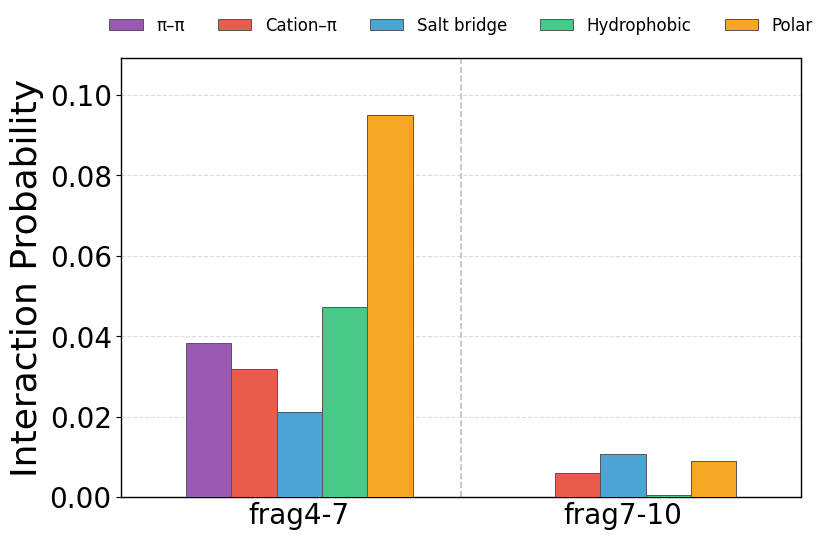

Saved PNG: /mmfs1/projects/chem_hzhou43/fhatami/project2/interaction_type_outputs_frag4-7_frag7-10/frag4-7_frag7-10_interaction_totals.png
Saved PDF: /mmfs1/projects/chem_hzhou43/fhatami/project2/interaction_type_outputs_frag4-7_frag7-10/frag4-7_frag7-10_interaction_totals.pdf


In [3]:
%matplotlib inline

# =============================================================================
# ONE PLOT: SUMMED INTERACTION PROBABILITIES FOR frag4-7 AND frag7-10
# =============================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# ---------------------------------------------------------------------------
# Input/output files
# ---------------------------------------------------------------------------
OUTPUT_DIR = Path("interaction_type_outputs_frag4-7_frag7-10")

INPUT_CSV = (
    OUTPUT_DIR
    / "interaction_dataset_totals_mean_over_trajs.csv"
)

OUTPUT_PNG = OUTPUT_DIR / "frag4-7_frag7-10_interaction_totals.png"
OUTPUT_PDF = OUTPUT_DIR / "frag4-7_frag7-10_interaction_totals.pdf"


# ---------------------------------------------------------------------------
# Plot order, names, and colors
# ---------------------------------------------------------------------------
DATASET_ORDER = ["frag4-7", "frag7-10"]

INTERACTION_ORDER = [
    "pi_pi",
    "cation_pi",
    "salt_bridge",
    "hydrophobic",
    "polar",
]

INTERACTION_LABELS = {
    "pi_pi": "π–π",
    "cation_pi": "Cation–π",
    "salt_bridge": "Salt bridge",
    "hydrophobic": "Hydrophobic",
    "polar": "Polar",
}

INTERACTION_COLORS = {
    "pi_pi": "#9B59B6",        # purple
    "cation_pi": "#E95B4B",    # red
    "salt_bridge": "#4CA3D4",  # blue
    "hydrophobic": "#48C987",  # green
    "polar": "#F5A623",        # orange
}


# ---------------------------------------------------------------------------
# Read results
# ---------------------------------------------------------------------------
if not INPUT_CSV.exists():
    raise FileNotFoundError(
        f"Could not find:\n{INPUT_CSV.resolve()}\n"
        "Run the interaction-analysis cell first."
    )

df = pd.read_csv(INPUT_CSV)

required_columns = {
    "dataset",
    "interaction",
    "total_mean_probability",
}

missing = required_columns.difference(df.columns)

if missing:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(sorted(missing))
    )


# Keep only the requested datasets and interaction types
df_plot = df[
    df["dataset"].isin(DATASET_ORDER)
    & df["interaction"].isin(INTERACTION_ORDER)
].copy()


# Create dataset × interaction table
plot_table = (
    df_plot.pivot_table(
        index="dataset",
        columns="interaction",
        values="total_mean_probability",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(
        index=DATASET_ORDER,
        columns=INTERACTION_ORDER,
        fill_value=0.0,
    )
)

print("Summed probabilities used in the plot:")
display(plot_table)


# ---------------------------------------------------------------------------
# Create one grouped bar plot
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.5, 5.5))

x = np.arange(len(DATASET_ORDER))

bar_width = 0.14
number_of_types = len(INTERACTION_ORDER)
center_index = (number_of_types - 1) / 2

for i, interaction in enumerate(INTERACTION_ORDER):

    bar_offset = (i - center_index) * bar_width

    ax.bar(
        x + bar_offset,
        plot_table[interaction].to_numpy(dtype=float),
        width=bar_width,
        color=INTERACTION_COLORS[interaction],
        edgecolor="#555555",
        linewidth=0.7,
        label=INTERACTION_LABELS[interaction],
        zorder=3,
    )


# ---------------------------------------------------------------------------
# ---------------------------------------------------------------------------
# ---------------------------------------------------------------------------
# Separator between the two fragment datasets
# ---------------------------------------------------------------------------
ax.axvline(
    x=0.5,
    color="#BDBDBD",
    linestyle="--",
    linewidth=1.2,
    zorder=1,
)

# ---------------------------------------------------------------------------
# Light-gray horizontal grid
# ---------------------------------------------------------------------------
ax.set_axisbelow(True)

ax.grid(
    axis="y",
    color="#D3D3D3",
    linestyle="--",
    linewidth=0.8,
    alpha=0.75,
)

# ---------------------------------------------------------------------------
# Complete box around the plotting area
# ---------------------------------------------------------------------------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.0)

# ---------------------------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(
    ["frag4-7", "frag7-10"],
    fontsize=26,
)

ax.set_xlabel("")
ax.set_ylabel(
    "Interaction Probability",
    fontsize=26,
)

ax.set_xlim(-0.55, 1.55)

maximum_value = plot_table.to_numpy(dtype=float).max()

ax.set_ylim(
    0,
    max(maximum_value * 1.15, 1e-8),
)

ax.tick_params(
    axis="both",
    labelsize=20,
    direction="out",
)

ax.tick_params(axis="x", length=0)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False,
    fontsize=12,
)

fig.tight_layout()

# ---------------------------------------------------------------------------
# Save and show only once
# ---------------------------------------------------------------------------
fig.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_PDF,
    bbox_inches="tight",
)

plt.show()  # Render the figure only once

print(f"Saved PNG: {OUTPUT_PNG.resolve()}")
print(f"Saved PDF: {OUTPUT_PDF.resolve()}")


Reading saved matrices for frag4-7:


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for /mmfs1/projects/chem_hzhou43/fhatami/project2/frag4-7/out.center/prmtop.0d3_a_no_water_caprin.parm7. Skipping this file.
  warnings.warn(


  pi_pi       : frag4-7/dataset_matrices-single-type-pi_pi/frag4-7_pi_pi_matrix.csv
  cation_pi   : frag4-7/dataset_matrices-single-type-cation_pi/frag4-7_cation_pi_matrix.csv
  salt_bridge : frag4-7/dataset_matrices-single-type-salt_bridge/frag4-7_salt_bridge_matrix.csv
  Y-axis sequence: G F R G G Y D G Y R P S F S N T
  X-axis sequence: Q F S A P R D Y S G Y Q R D G Y
  Matrix shape: (16, 16)
  Maximum cell value: 0.015873
  Matrix sum: 0.091123
  Saved combined matrix: /mmfs1/projects/chem_hzhou43/fhatami/project2/interaction_type_outputs_frag4-7_frag7-10/three_interaction_contact_maps/frag4-7_pi_pi_cation_pi_salt_bridge_probability_matrix_16x16.csv

Reading saved matrices for frag7-10:


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for /mmfs1/projects/chem_hzhou43/fhatami/project2/frag7-10/out.center/prmtop.0d3_a_no_water_caprin.parm7. Skipping this file.
  warnings.warn(


  pi_pi       : frag7-10/dataset_matrices-single-type-pi_pi/frag7-10_pi_pi_matrix.csv
  cation_pi   : frag7-10/dataset_matrices-single-type-cation_pi/frag7-10_cation_pi_matrix.csv
  salt_bridge : frag7-10/dataset_matrices-single-type-salt_bridge/frag7-10_salt_bridge_matrix.csv
  Y-axis sequence: G Q S G P R G A P R G R G G P P
  X-axis sequence: Q F S A P R D Y S G Y Q R D G Y
  Matrix shape: (16, 16)
  Maximum cell value: 0.008529
  Matrix sum: 0.016711
  Saved combined matrix: /mmfs1/projects/chem_hzhou43/fhatami/project2/interaction_type_outputs_frag4-7_frag7-10/three_interaction_contact_maps/frag7-10_pi_pi_cation_pi_salt_bridge_probability_matrix_16x16.csv


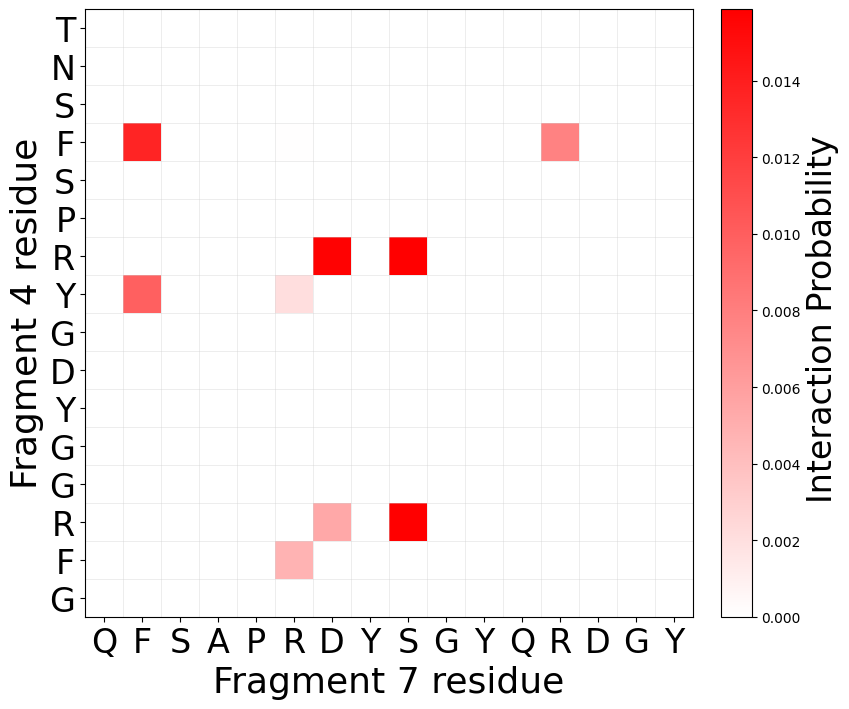

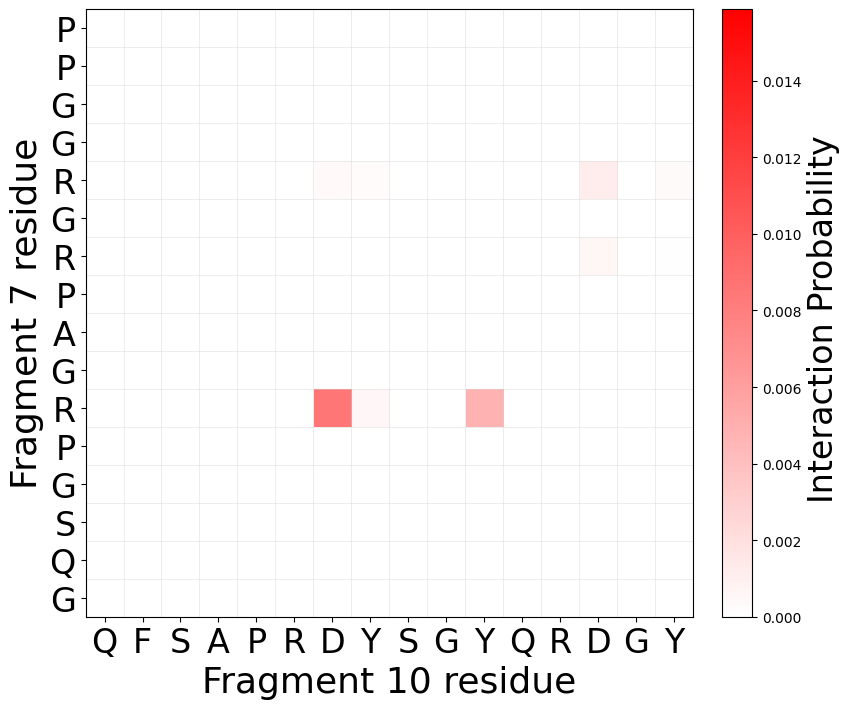

In [12]:
from pathlib import Path

import MDAnalysis as mda
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap


# =============================================================================
# PATHS AND SETTINGS
# =============================================================================

OUTPUT_DIR = Path(
    "/mmfs1/projects/chem_hzhou43/fhatami/project2/"
    "interaction_type_outputs_frag4-7_frag7-10"
)

PROJECT_DIR = OUTPUT_DIR.parent

PLOT_OUTPUT_DIR = OUTPUT_DIR / "three_interaction_contact_maps"
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


INTERACTIONS_TO_SUM = (
    "pi_pi",
    "cation_pi",
    "salt_bridge",
)


DATASETS = {
    "frag4-7": {
        "y_fragment": "Fragment 4",
        "x_fragment": "Fragment 7",
        "topology": (
            PROJECT_DIR
            / "frag4-7"
            / "out.center"
            / "prmtop.0d3_a_no_water_caprin.parm7"
        ),
    },
    "frag7-10": {
        "y_fragment": "Fragment 7",
        "x_fragment": "Fragment 10",
        "topology": (
            PROJECT_DIR
            / "frag7-10"
            / "out.center"
            / "prmtop.0d3_a_no_water_caprin.parm7"
        ),
    },
}


# Exact white-to-red scale: low = white, high = red
COLORMAP = LinearSegmentedColormap.from_list(
    "white_to_red",
    ["#FFFFFF", "#FF0000"],
)


FIGURE_DPI = 600
USE_SHARED_COLOR_SCALE = True
ANNOTATE_CELLS = False


AA3_TO_AA1 = {
    "ALA": "A",
    "ARG": "R",
    "ASN": "N",
    "ASP": "D",
    "ASH": "D",
    "CYS": "C",
    "CYM": "C",
    "CYX": "C",
    "GLN": "Q",
    "GLU": "E",
    "GLH": "E",
    "GLY": "G",
    "HIS": "H",
    "HID": "H",
    "HIE": "H",
    "HIP": "H",
    "ILE": "I",
    "LEU": "L",
    "LYS": "K",
    "LYN": "K",
    "MET": "M",
    "PHE": "F",
    "PRO": "P",
    "SER": "S",
    "THR": "T",
    "TRP": "W",
    "TYR": "Y",
    "VAL": "V",
}


# =============================================================================
# READ THE TWO 16-RESIDUE SEQUENCES FROM EACH TOPOLOGY
# This reads residue names only. It does not read trajectories or recalculate
# any interaction probability.
# =============================================================================

def get_uncapped_peptide_chains(topology_path):
    """
    Return the real peptide sequence of every ACE ... NME chain.

    Each returned chain is a tuple of three-letter residue names with the
    terminal ACE and NME caps removed.
    """

    if not topology_path.is_file():
        raise FileNotFoundError(
            f"Topology file was not found:\n{topology_path}"
        )

    universe = mda.Universe(str(topology_path))

    chains = []
    current_chain = []
    inside_chain = False

    for residue in universe.residues:
        residue_name = str(residue.resname).upper()

        if residue_name == "ACE":
            if inside_chain and current_chain:
                chains.append(tuple(current_chain))

            current_chain = []
            inside_chain = True
            continue

        if not inside_chain:
            continue

        if residue_name == "NME":
            if current_chain:
                chains.append(tuple(current_chain))

            current_chain = []
            inside_chain = False
            continue

        current_chain.append(residue_name)

    if inside_chain and current_chain:
        chains.append(tuple(current_chain))

    if not chains:
        raise ValueError(
            f"No ACE ... NME peptide chains were found in:\n{topology_path}"
        )

    return chains


def convert_to_one_letter_labels(sequence):
    """Convert a three-letter sequence to labels such as R, D, and Y."""

    labels = []

    for residue_name in sequence:
        if residue_name not in AA3_TO_AA1:
            raise ValueError(
                f"No one-letter amino-acid code is defined for "
                f"residue name {residue_name!r}."
            )

        # Deliberately do not append the residue-position number.
        labels.append(AA3_TO_AA1[residue_name])

    return labels


def get_axis_residue_labels(dataset_name, dataset_info):
    """
    Obtain the Y/source and X/target sequences from the topology.

    The first chain type is the Y/source fragment, matching the orientation
    used when the saved matrices were generated. The other chain type is the
    X/target fragment.
    """

    chains = get_uncapped_peptide_chains(dataset_info["topology"])

    source_sequence = chains[0]

    target_sequences = []

    for chain in chains:
        if chain != source_sequence and chain not in target_sequences:
            target_sequences.append(chain)

    if len(target_sequences) != 1:
        distinct_sequences = []

        for chain in chains:
            if chain not in distinct_sequences:
                distinct_sequences.append(chain)

        raise ValueError(
            f"{dataset_name}: expected exactly two distinct peptide "
            f"sequences, but found {len(distinct_sequences)}."
        )

    target_sequence = target_sequences[0]

    if len(source_sequence) != 16 or len(target_sequence) != 16:
        raise ValueError(
            f"{dataset_name}: expected two 16-residue fragments, but found "
            f"lengths {len(source_sequence)} and {len(target_sequence)}."
        )

    source_labels = convert_to_one_letter_labels(source_sequence)
    target_labels = convert_to_one_letter_labels(target_sequence)

    return source_labels, target_labels


# =============================================================================
# READ A SAVED NUMERIC 16x16 MATRIX
# =============================================================================

def try_read_16x16_matrix(csv_path):
    """
    Try several common CSV layouts and return the numeric 16x16 matrix.
    """

    reading_options = (
        {"header": None},
        {"header": 0},
        {"header": 0, "index_col": 0},
        {"header": None, "index_col": 0},
    )

    for options in reading_options:
        try:
            dataframe = pd.read_csv(csv_path, **options)

            numeric_dataframe = dataframe.apply(
                pd.to_numeric,
                errors="raise",
            )

            matrix = numeric_dataframe.to_numpy(dtype=float)

            if matrix.shape == (16, 16):
                if not np.isfinite(matrix).all():
                    raise ValueError(
                        f"{csv_path} contains NaN or infinite values."
                    )

                return matrix

        except (ValueError, TypeError, pd.errors.ParserError):
            continue

    return None


def find_saved_interaction_matrix(dataset_name, interaction_name):
    """
    Read the exact matrix filename, ignoring .ipynb_checkpoints.
    """

    matrix_directory = (
        OUTPUT_DIR
        / dataset_name
        / f"dataset_matrices-single-type-{interaction_name}"
    )

    matrix_path = (
        matrix_directory
        / f"{dataset_name}_{interaction_name}_matrix.csv"
    )

    if not matrix_path.is_file():
        raise FileNotFoundError(
            f"Expected matrix was not found:\n{matrix_path}"
        )

    matrix = try_read_16x16_matrix(matrix_path)

    if matrix is None:
        raise ValueError(
            f"The following file is not a valid numeric 16x16 matrix:\n"
            f"{matrix_path}"
        )

    return matrix_path, matrix


# =============================================================================
# READ AND SUM THE THREE SAVED MATRICES
# =============================================================================

combined_results = {}

for dataset_name, dataset_info in DATASETS.items():
    print(f"\nReading saved matrices for {dataset_name}:")

    source_labels, target_labels = get_axis_residue_labels(
        dataset_name,
        dataset_info,
    )

    interaction_matrices = []

    for interaction_name in INTERACTIONS_TO_SUM:
        matrix_path, matrix = find_saved_interaction_matrix(
            dataset_name,
            interaction_name,
        )

        interaction_matrices.append(matrix)

        print(
            f"  {interaction_name:12s}: "
            f"{matrix_path.relative_to(OUTPUT_DIR)}"
        )

    combined_matrix = np.sum(interaction_matrices, axis=0)

    combined_results[dataset_name] = {
        "matrix": combined_matrix,
        "source_labels": source_labels,
        "target_labels": target_labels,
    }

    # Keep this file as a raw numeric 16x16 matrix.
    combined_csv_path = PLOT_OUTPUT_DIR / (
        f"{dataset_name}_pi_pi_cation_pi_salt_bridge"
        f"_probability_matrix_16x16.csv"
    )

    pd.DataFrame(combined_matrix).to_csv(
        combined_csv_path,
        index=False,
        header=False,
        float_format="%.10g",
    )

    print(f"  Y-axis sequence: {' '.join(source_labels)}")
    print(f"  X-axis sequence: {' '.join(target_labels)}")
    print(f"  Matrix shape: {combined_matrix.shape}")
    print(f"  Maximum cell value: {combined_matrix.max():.6f}")
    print(f"  Matrix sum: {combined_matrix.sum():.6f}")
    print(f"  Saved combined matrix: {combined_csv_path}")


# =============================================================================
# SELECT THE COLOR SCALE
# =============================================================================

if USE_SHARED_COLOR_SCALE:
    shared_vmax = max(
        float(result["matrix"].max())
        for result in combined_results.values()
    )
    shared_vmax = max(shared_vmax, 1e-12)
else:
    shared_vmax = None


# =============================================================================
# PLOT THE TWO CONTACT MAPS WITH RESIDUE-NAME LABELS
# =============================================================================

for dataset_name, dataset_info in DATASETS.items():
    result = combined_results[dataset_name]

    matrix = result["matrix"]
    source_labels = result["source_labels"]
    target_labels = result["target_labels"]

    local_vmax = (
        shared_vmax
        if USE_SHARED_COLOR_SCALE
        else max(float(matrix.max()), 1e-12)
    )

    fig, ax = plt.subplots(figsize=(8.5, 7.2))

    image = ax.imshow(
        matrix,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap=COLORMAP,
        vmin=0.0,
        vmax=local_vmax,
    )

    ax.set_xticks(np.arange(16))
    ax.set_yticks(np.arange(16))

    # Use only one-letter residue names: R, Y, D, etc.; no numbers.
    ax.set_xticklabels(
        target_labels,
        fontsize=24,
    )
    ax.set_yticklabels(
        source_labels,
        fontsize=24,
    )

    # Cell borders
    ax.set_xticks(np.arange(-0.5, 16, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 16, 1), minor=True)

    ax.grid(
        which="minor",
        color="lightgray",
        linewidth=0.4,
        alpha=0.7,
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

    ax.set_xlabel(
        f"{dataset_info['x_fragment']} residue",
        fontsize=26,
    )

    ax.set_ylabel(
        f"{dataset_info['y_fragment']} residue",
        fontsize=26,
    )

    # ax.set_title(
    #     f"{dataset_info['y_fragment']}–"
    #     f"{dataset_info['x_fragment']}\n"
    #     r"$\pi$–$\pi$ + cation–$\pi$ + salt-bridge",
    #     fontsize=13,
    #     fontweight="bold",
    # )

    if ANNOTATE_CELLS:
        text_threshold = 0.5 * local_vmax

        for y_index in range(16):
            for x_index in range(16):
                value = matrix[y_index, x_index]

                ax.text(
                    x_index,
                    y_index,
                    f"{value:.3f}",
                    ha="center",
                    va="center",
                    fontsize=5,
                    color=(
                        "white"
                        if value > text_threshold
                        else "black"
                    ),
                )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    colorbar.set_label(
        r"Interaction Probability ",
        fontsize=24,
    )

    fig.tight_layout()

    png_path = PLOT_OUTPUT_DIR / (
        f"{dataset_name}_three_interaction_contact_map.png"
    )

    pdf_path = PLOT_OUTPUT_DIR / (
        f"{dataset_name}_three_interaction_contact_map.pdf"
    )

    fig.savefig(
        png_path,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    plt.show()
    plt.show(fig)

